In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b4= bd.iloc[71]

In [4]:
b4['datetime']

'2020-04-05,12:03:17.539867+00:00'

In [5]:
lat= literal_eval(b4['lat_stereo_g17'])
long= literal_eval(b4['lon_stereo_g17'])
alt= literal_eval(b4['alt_stereo_g17'])
energy = literal_eval(b4['energyJoules_stereo_g17'])

In [6]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [7]:
print (len(lat), len(long), len(alt), len(energy))

20 20 20 20


In [8]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

10


In [9]:
totalmass= 0
totalh= 0 
for i in range (10): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [10]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

6.42100255039582e-07 2.9964678568513827e-07 2.996467856851382e-06


In [11]:
totalh

43.481064663709574

In [12]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

-0.0035154199999993807
0.0010034700000005614
0.0032673799999969333
0.008045620000004305
-0.0009957500000012942
-0.0007144100000004983
1.2400000002799061e-05
0.0014734300000043277
0.0014739299999888544
0.001217220000000907
0.0009726800000038338
-1.8889999992666162e-05
-0.0012589000000104988
-0.0009957099999979846
-0.0012542500000023438
-0.0012526599999915788
-0.00024901999999826785
0.0005060499999984813
0.0007501500000017813


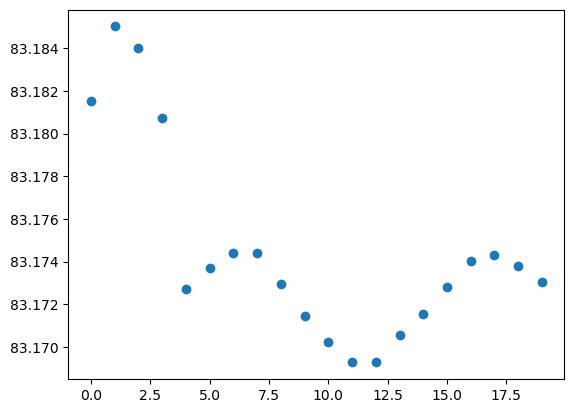

In [13]:
plt.scatter(range(len(alt)), alt)